####  question 4:
By combining "sitting" and "standing" into one class, the model's task becomes easier for these activities, so we observe higher accuracy for the new "sitstand" class and possibly a higher overall accuracy. This approach is useful when the distinction between sitting and standing is less important than distinguishing them from other activities.

In [2]:
import pandas as pd
import numpy as np
# Load the main features DataFrame
features_df = pd.read_csv('Data/features_df.csv')

# Combine 'sitting' and 'standing' into 'sitstand', comment/uncommet the next line if needed
def combine_labels(df):
    df = df.copy()
    df['majority_activity'] = df['majority_activity'].replace({'sitting': 'sitstand', 'standing': 'sitstand'})
    df['majority_activity'] = df['majority_activity'].replace({'downstairs': 'downups', 'upstairs': 'downups'})
    return df

features_comb = combine_labels(features_df)
participants = features_comb['participant'].unique()

Participant 1 - Accuracy: 0.930
Participant 2 - Accuracy: 0.948
Participant 3 - Accuracy: 0.938
Participant 4 - Accuracy: 0.828
Participant 5 - Accuracy: 0.833
Participant 6 - Accuracy: 0.954
Participant 7 - Accuracy: 0.783
Participant 8 - Accuracy: 0.977
Participant 9 - Accuracy: 0.763
Participant 10 - Accuracy: 0.828

Mean LOSO Accuracy (sitstand combined): 0.878


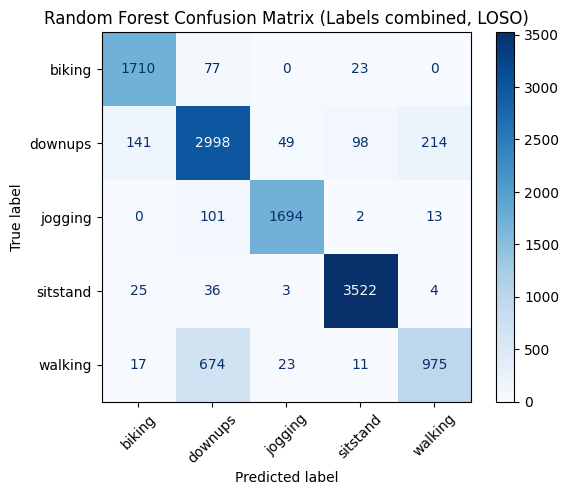

In [7]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



rf_params = {
    'n_estimators': 150,
    'max_depth': 10,
    'min_samples_split': 5,
    'max_features': 'sqrt',
    'criterion': 'entropy',
    'random_state': 28
}

results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_comb[features_comb['participant'] != pid]
    test_df = features_comb[features_comb['participant'] == pid]
    
    X_train = train_df.drop(['majority_activity', 'participant'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant'], axis=1)
    y_test = test_df['majority_activity']
    
    clf = RandomForestClassifier(**rf_params)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({'participant': pid, 'accuracy': acc})
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO Accuracy (sitstand combined): {mean_acc:.3f}")

# Confusion matrix
class_names = sorted(list(set(all_y_true) | set(all_y_pred)))
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix (Labels combined, LOSO)")
plt.xticks(rotation=45)
plt.show()


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      biking       0.97      0.84      0.90       181
     downups       0.63      1.00      0.78       350
     jogging       1.00      0.98      0.99       181
    sitstand       1.00      0.97      0.99       359
     walking       0.00      0.00      0.00       170

    accuracy                           0.83      1241
   macro avg       0.72      0.76      0.73      1241
weighted avg       0.76      0.83      0.78      1241



#### SVM grouped labels


SVM Participant 1 - Accuracy: 0.960
SVM Participant 2 - Accuracy: 0.980
SVM Participant 3 - Accuracy: 0.926
SVM Participant 4 - Accuracy: 0.960
SVM Participant 5 - Accuracy: 0.969
SVM Participant 6 - Accuracy: 0.973
SVM Participant 7 - Accuracy: 0.937
SVM Participant 8 - Accuracy: 0.929
SVM Participant 9 - Accuracy: 0.912
SVM Participant 10 - Accuracy: 0.928

Mean LOSO Accuracy (SVM, RBF kernel): 0.947


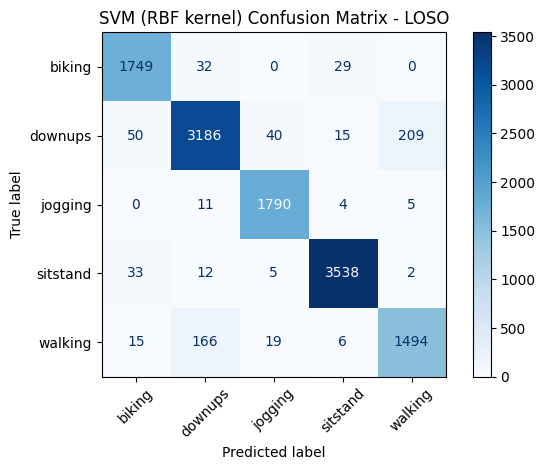

              precision    recall  f1-score   support

      biking       0.95      0.97      0.96      1810
     downups       0.94      0.91      0.92      3500
     jogging       0.97      0.99      0.98      1810
    sitstand       0.98      0.99      0.99      3590
     walking       0.87      0.88      0.88      1700

    accuracy                           0.95     12410
   macro avg       0.94      0.95      0.94     12410
weighted avg       0.95      0.95      0.95     12410



In [6]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

svm_results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    # Split data
    train_df = features_comb[features_comb['participant'] != pid]
    test_df = features_comb[features_comb['participant'] == pid]
    
    # Features and labels
    X_train = train_df.drop(['majority_activity', 'participant'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant'], axis=1)
    y_test = test_df['majority_activity']
    
    # Feature count for gamma
    n_features = X_train.shape[1]

    # Train SVM classifier (polynomial kernel)
   # svm_clf = SVC(kernel='poly', C=0.1, gamma=1/n_features, degree=2, random_state=42)
    svm_clf = SVC(kernel='rbf', C=10, gamma=1/n_features, random_state=42)

    svm_clf.fit(X_train, y_train)
    
    # Predict
    y_pred = svm_clf.predict(X_test)
    
    # Save results
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    svm_results.append({'participant': pid, 'accuracy': acc, 'report': report})

    print(f"SVM Participant {pid} - Accuracy: {acc:.3f}")

# Mean LOSO Accuracy
mean_svm_acc = np.mean([r['accuracy'] for r in svm_results])
print(f"\nMean LOSO Accuracy (SVM, RBF kernel): {mean_svm_acc:.3f}")

# Confusion Matrix
class_names = sorted(list(set(all_y_true) | set(all_y_pred)))
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM (RBF kernel) Confusion Matrix - LOSO")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(classification_report(all_y_true, all_y_pred, target_names=class_names))

#### MLP grouped labels


Participant 1 - Accuracy: 0.981
Participant 2 - Accuracy: 0.952
Participant 3 - Accuracy: 0.948
Participant 4 - Accuracy: 0.927
Participant 5 - Accuracy: 0.959
Participant 6 - Accuracy: 0.971
Participant 7 - Accuracy: 0.956
Participant 8 - Accuracy: 0.892
Participant 9 - Accuracy: 0.940
Participant 10 - Accuracy: 0.944

Mean LOSO MLP Accuracy: 0.947


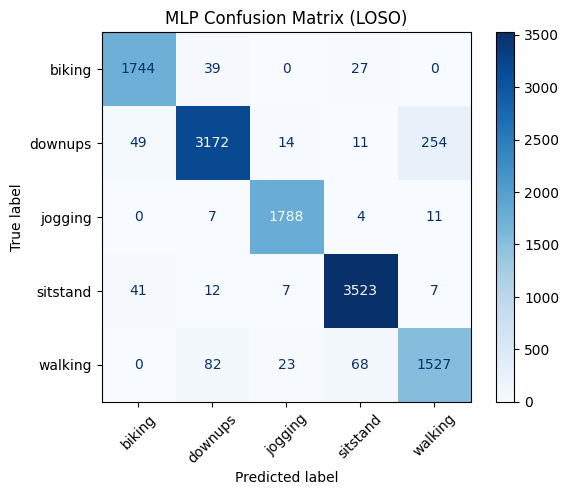

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# LOSO cross-validation for MLP
results = []
all_y_true = []
all_y_pred = []

for pid in participants:
    train_df = features_comb[features_comb['participant'] != pid]
    test_df = features_comb[features_comb['participant'] == pid]
    
    X_train = train_df.drop(['majority_activity', 'participant'], axis=1)
    y_train = train_df['majority_activity']
    X_test = test_df.drop(['majority_activity', 'participant'], axis=1)
    y_test = test_df['majority_activity']
    
    mlp = MLPClassifier(hidden_layer_sizes=(20, 20), solver='sgd', activation='tanh',
                        alpha=0.001, momentum=0.95, max_iter=500, random_state=42)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({'participant': pid, 'accuracy': acc})
    print(f"Participant {pid} - Accuracy: {acc:.3f}")

mean_acc = np.mean([r['accuracy'] for r in results])
print(f"\nMean LOSO MLP Accuracy: {mean_acc:.3f}")

# Confusion matrix for all predictions
class_names = sorted(list(set(all_y_true) | set(all_y_pred)))
cm = confusion_matrix(all_y_true, all_y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("MLP Confusion Matrix (LOSO)")
plt.xticks(rotation=45)
plt.show()